In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

limit = 15
# Load CSV file
sheet_id = "1tEf8J1kbGZEFTOkoYqIjsdE3PkqBA9bX4MdNfMoLhjQ"
# tab_gid = "908803302"
tab_gid = "1990888583" 
full_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={tab_gid}"
df = pd.read_csv(full_url, skiprows=2).iloc[:limit,:4]
df

,Model,Compression,Size (MB),BLEU
0,pythia-70M,Original,281.73,42.00
1,pythia-70M,8-bit,122.13,41.39
2,pythia-70M,4-bit,113.77,39.21
3,pythia-160M,Original,649.34,42.49
4,pythia-160M,8-bit,240.12,42.31
5,pythia-160M,4-bit,202.65,40.60
6,pythia-410M,Original,1621.43,43.51
7,pythia-410M,8-bit,509.70,43.61
8,pythia-410M,4-bit,376.75,42.41
9,pythia-1B,Original,4047.19,44.18


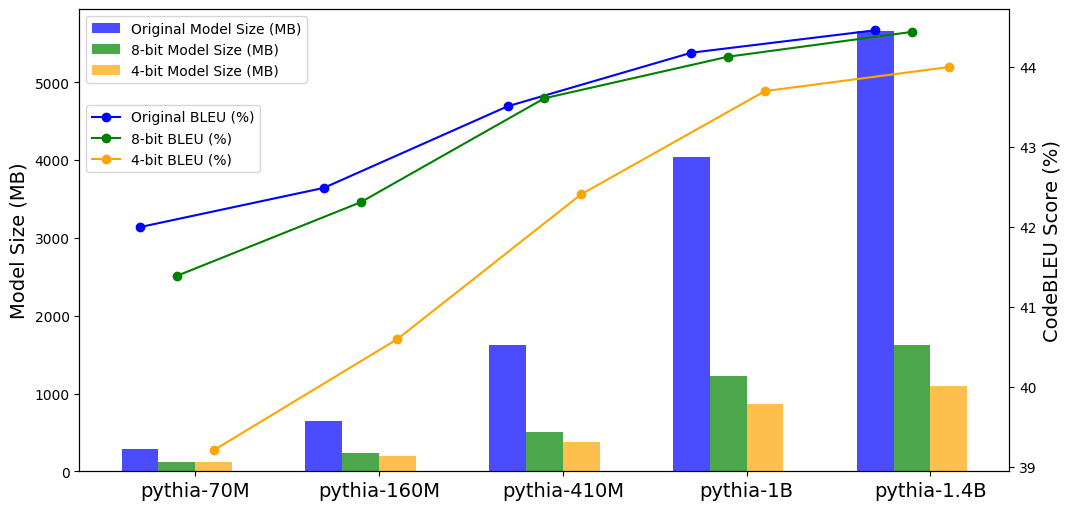

In [12]:

# Extract unique model names
models = df["Model"].unique()
compressions = df["Compression"].unique()

# Define bar width and colors
bar_width = 0.2
colors = ["blue", "green", "orange"]

x = np.arange(len(models))  # X-axis positions

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot bar chart for model sizes
for i, comp in enumerate(compressions):
    subset = df[df["Compression"] == comp]
    ax1.bar(x + i * bar_width, subset["Size (MB)"], width=bar_width, label=f"{comp} Model Size (MB)", alpha=0.7, color=colors[i])

ax1.set_ylabel("Model Size (MB)", fontsize=14)
ax1.set_xticks(x + bar_width * 1.5)
ax1.set_xticklabels(models, rotation=0, fontsize=14)
ax1.legend(loc="upper left")

# Second y-axis for performance scores
ax2 = ax1.twinx()

# Plot line chart for performance
for i, comp in enumerate(compressions):
    subset = df[df["Compression"] == comp]
    ax2.plot(x + i * bar_width, subset["BLEU"], marker="o", linestyle="-", label=f"{comp} BLEU (%)", color=colors[i])

ax2.set_ylabel("CodeBLEU Score (%)", fontsize=14)
ax2.legend(loc="center left", bbox_to_anchor=(0, 0.72))

# plt.title("Comparison of Model Sizes and Performance Across Compression Levels")
plt.savefig(f"./output/model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()